In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [2]:
# loading the dataset
df = pd.read_csv("../datasets/Pd_nanoparticle/Pd_nanoparticle_dataset.csv")
df

,ID,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,...,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+,Surf_defects_mol,Surf_micros_mol,Surf_facets_mol,Total_E,Formation_E
0,1,273,0.000025,1,1790,1176,614,2.630000e-26,15.0138,18.8502,...,0,0,0,0,0,0.000,80.447,251.397,-6439.5349,559.3651
1,2,273,0.000025,2,1839,1206,633,2.700000e-26,15.3411,19.8051,...,0,0,0,0,0,0.544,79.391,256.661,-6586.9485,603.5415
2,3,273,0.000025,3,4838,3496,1342,7.110000e-26,19.6162,31.1116,...,0,0,0,0,0,0.827,86.399,186.647,-17695.5310,1221.0490
3,4,273,0.000025,4,7337,5410,1927,1.080000e-25,21.6702,37.8163,...,0,0,0,0,0,0.545,80.960,178.956,-26902.9580,1784.7120
4,5,273,0.000025,5,11102,8478,2624,1.630000e-25,23.3898,45.4491,...,0,0,0,0,0,0.540,72.780,161.052,-40876.0580,2532.7620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,973,0.000250,6,1676,1050,626,2.460000e-26,11.4822,26.1028,...,0,0,0,0,0,0.000,102.625,261.933,-5852.2527,700.9073
3996,3997,973,0.000250,7,1915,1241,674,2.810000e-26,12.8857,26.7585,...,0,0,0,0,0,0.000,97.128,252.219,-6719.0509,768.5991
3997,3998,973,0.000250,8,2204,1438,766,3.240000e-26,12.4847,28.7650,...,0,0,0,0,0,0.454,97.096,246.370,-7762.6469,854.9931
3998,3999,973,0.000250,9,2746,1841,905,4.040000e-26,12.5210,31.3819,...,0,0,0,0,0,0.000,93.955,232.702,-9707.9804,1028.8796


In [3]:
df = df.drop(['ID'], axis=1)
print(df[df.duplicated(keep=False)])

        T  tau  time  N_total  N_bulk  N_surface        Volume    R_min  \
423   323  0.0    10     1163     639        524  1.710000e-26  12.3833   
424   323  0.0    10     1163     639        524  1.710000e-26  12.3833   
1423  523  0.0    10     1163     674        489  1.710000e-26  12.4841   
1424  523  0.0    10     1163     674        489  1.710000e-26  12.4841   
2423  723  0.0    10     1163     697        466  1.710000e-26  12.4790   
2424  723  0.0    10     1163     697        466  1.710000e-26  12.4790   
3423  923  0.0    10     1163     713        450  1.710000e-26  12.5175   
3424  923  0.0    10     1163     713        450  1.710000e-26  12.5175   

        R_max  R_diff  ...  q6q6_S17  q6q6_S18  q6q6_S19  q6q6_S20  q6q6_S20+  \
423   19.1260  6.7427  ...         0         0         0         0          0   
424   19.1260  6.7427  ...         0         0         0         0          0   
1423  19.0312  6.5471  ...         0         0         0         0          0   


In [4]:
df = df.drop_duplicates()

In [5]:
df

,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,R_diff,...,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+,Surf_defects_mol,Surf_micros_mol,Surf_facets_mol,Total_E,Formation_E
0,273,0.000025,1,1790,1176,614,2.630000e-26,15.0138,18.8502,3.8363,...,0,0,0,0,0,0.000,80.447,251.397,-6439.5349,559.3651
1,273,0.000025,2,1839,1206,633,2.700000e-26,15.3411,19.8051,4.4640,...,0,0,0,0,0,0.544,79.391,256.661,-6586.9485,603.5415
2,273,0.000025,3,4838,3496,1342,7.110000e-26,19.6162,31.1116,11.4955,...,0,0,0,0,0,0.827,86.399,186.647,-17695.5310,1221.0490
3,273,0.000025,4,7337,5410,1927,1.080000e-25,21.6702,37.8163,16.1461,...,0,0,0,0,0,0.545,80.960,178.956,-26902.9580,1784.7120
4,273,0.000025,5,11102,8478,2624,1.630000e-25,23.3898,45.4491,22.0593,...,0,0,0,0,0,0.540,72.780,161.052,-40876.0580,2532.7620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,973,0.000250,6,1676,1050,626,2.460000e-26,11.4822,26.1028,14.6207,...,0,0,0,0,0,0.000,102.625,261.933,-5852.2527,700.9073
3996,973,0.000250,7,1915,1241,674,2.810000e-26,12.8857,26.7585,13.8728,...,0,0,0,0,0,0.000,97.128,252.219,-6719.0509,768.5991
3997,973,0.000250,8,2204,1438,766,3.240000e-26,12.4847,28.7650,16.2803,...,0,0,0,0,0,0.454,97.096,246.370,-7762.6469,854.9931
3998,973,0.000250,9,2746,1841,905,4.040000e-26,12.5210,31.3819,18.8609,...,0,0,0,0,0,0.000,93.955,232.702,-9707.9804,1028.8796


In [6]:
print(df[df.duplicated(keep=False)])

Empty DataFrame
Columns: [T, tau, time, N_total, N_bulk, N_surface, Volume, R_min, R_max, R_diff, R_avg, R_std, R_skew, R_kurt, S_100, S_111, S_110, S_311, Curve_1-10, Curve_11-20, Curve_21-30, Curve_31-40, Curve_41-50, Curve_51-60, Curve_61-70, Curve_71-80, Curve_81-90, Curve_91-100, Curve_101-110, Curve_111-120, Curve_121-130, Curve_131-140, Curve_141-150, Curve_151-160, Curve_161-170, Curve_171-180, Avg_total, Avg_bulk, Avg_surf, TCN_0, TCN_1, TCN_2, TCN_3, TCN_4, TCN_5, TCN_6, TCN_7, TCN_8, TCN_9, TCN_10, TCN_11, TCN_12, TCN_13, TCN_14, TCN_15, TCN_16, TCN_17, TCN_18, TCN_19, TCN_20, BCN_0, BCN_1, BCN_2, BCN_3, BCN_4, BCN_5, BCN_6, BCN_7, BCN_8, BCN_9, BCN_10, BCN_11, BCN_12, BCN_13, BCN_14, BCN_15, BCN_16, BCN_17, BCN_18, BCN_19, BCN_20, SCN_0, SCN_1, SCN_2, SCN_3, SCN_4, SCN_5, SCN_6, SCN_7, SCN_8, SCN_9, SCN_10, SCN_11, SCN_12, SCN_13, SCN_14, SCN_15, SCN_16, SCN_17, SCN_18, ...]
Index: []

[0 rows x 187 columns]


In [7]:
df2 = df.groupby(['T']).size().reset_index().rename(columns={0:'count'})
df2

,T,count
0,273,100
1,303,100
2,323,699
3,373,100
4,423,100
5,473,100
6,523,699
7,573,100
8,623,100
9,673,100


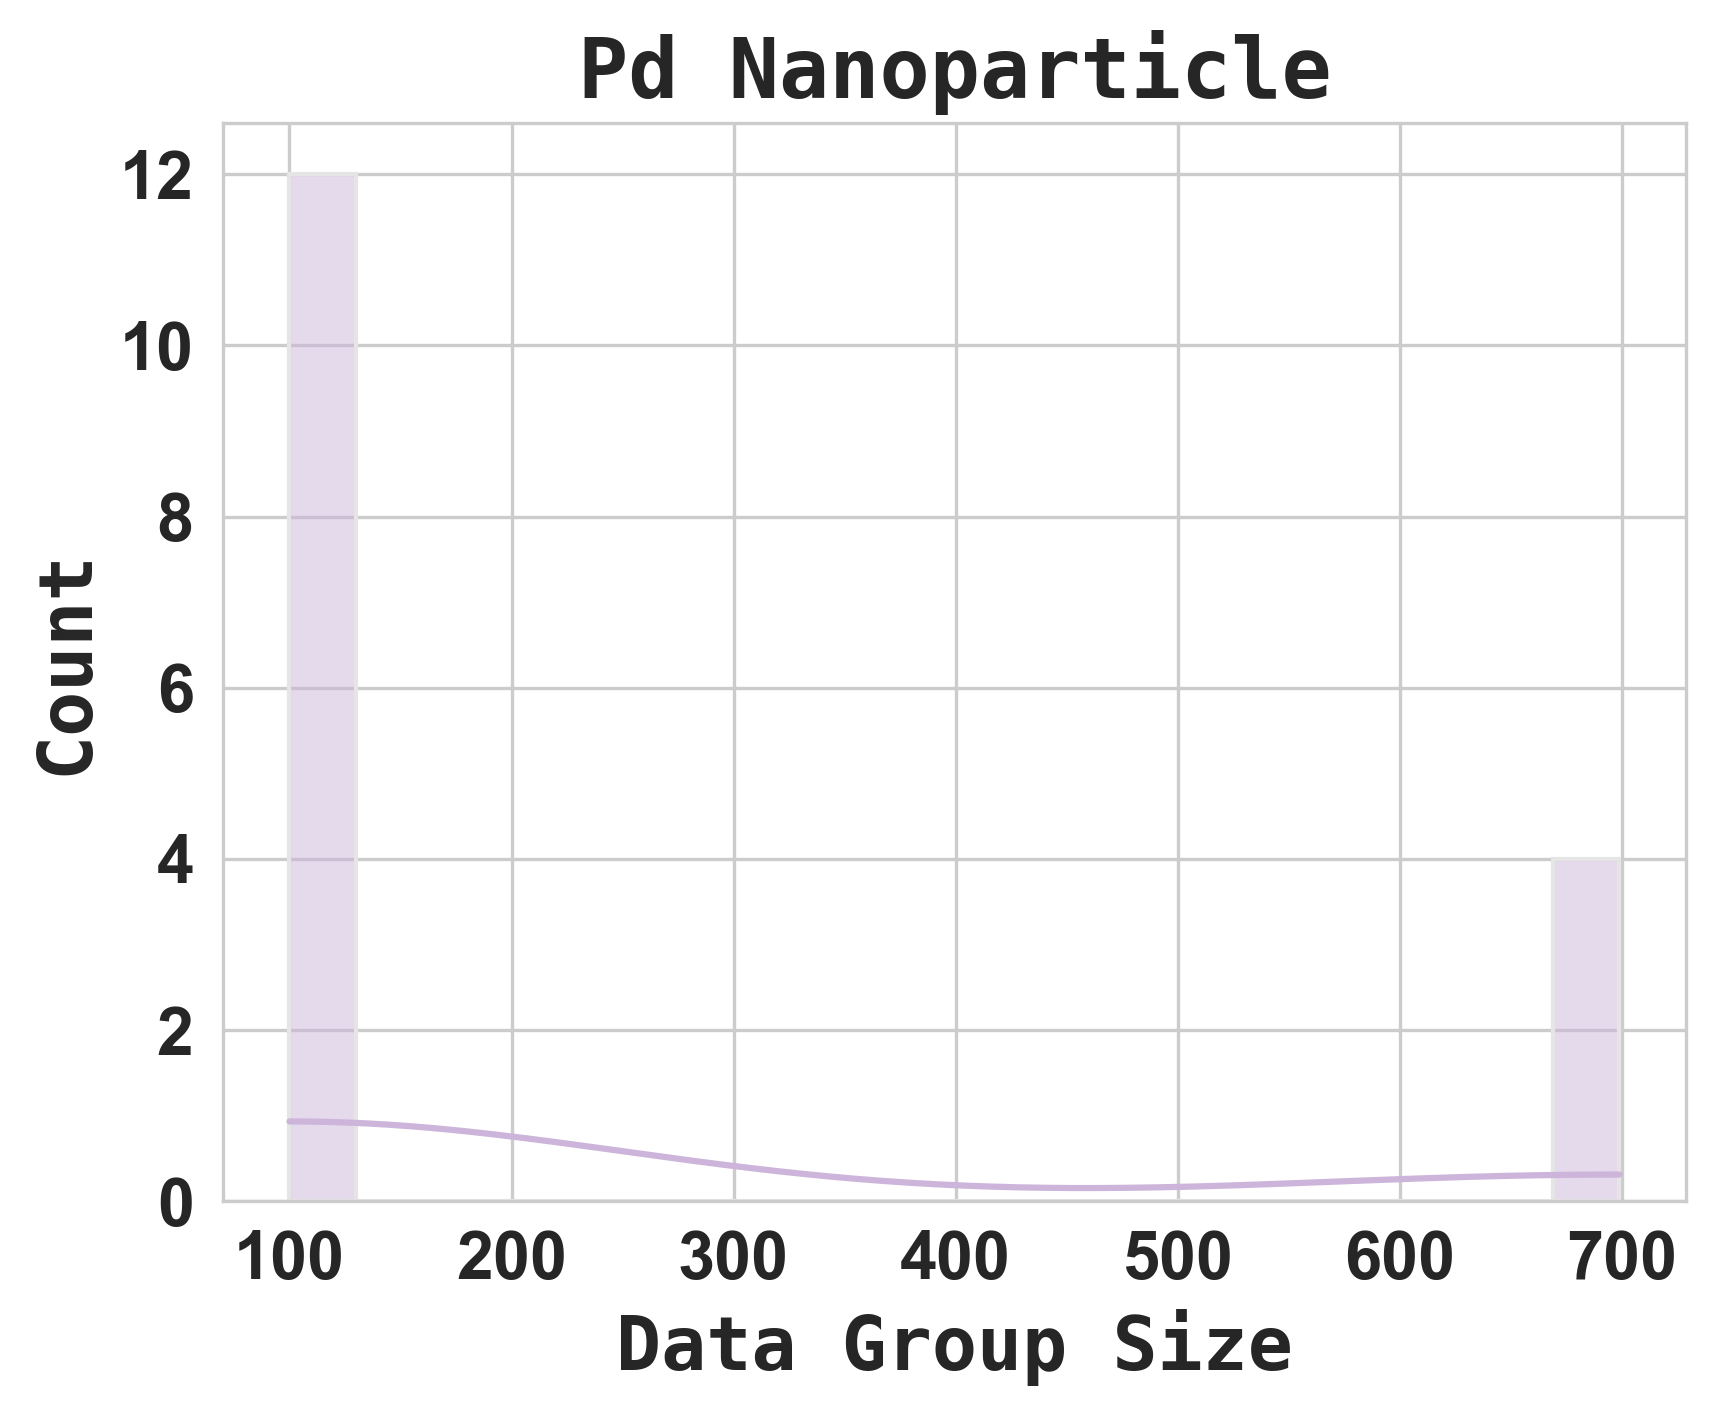

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create the plot
font = {'family': 'monospace', 'size': 16, 'weight':'bold'}
plt.rc('font', **font)
plt.rcParams['font.family'] = 'monospace'

sns.set_style("whitegrid")
plt.figure(figsize=(6, 5), dpi=300)

sns.histplot(data=df2, x='count', kde=True, color='#cdb4db', edgecolor='#e5e5e5',bins=20)

plt.title('Pd Nanoparticle', fontsize=20, fontname="monospace",weight='bold')
plt.xlabel('Data Group Size', fontsize=18, fontname="monospace", weight='bold')
plt.ylabel('Count', fontsize=18, fontname="monospace", weight='bold')

# Show the plot
plt.tight_layout()
plt.savefig('Pd_hist.png',
               bbox_inches="tight",
               pad_inches=0.05)
plt.show()

In [9]:
df_subset = df.drop(['Surf_defects_mol', 'Surf_micros_mol', 'Surf_facets_mol', 'Total_E', 'Formation_E'], axis=1)

In [10]:
df_subset

,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,R_diff,...,q6q6_S12,q6q6_S13,q6q6_S14,q6q6_S15,q6q6_S16,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+
0,273,0.000025,1,1790,1176,614,2.630000e-26,15.0138,18.8502,3.8363,...,0,0,0,0,0,0,0,0,0,0
1,273,0.000025,2,1839,1206,633,2.700000e-26,15.3411,19.8051,4.4640,...,1,0,0,0,0,0,0,0,0,0
2,273,0.000025,3,4838,3496,1342,7.110000e-26,19.6162,31.1116,11.4955,...,3,0,0,0,0,0,0,0,0,0
3,273,0.000025,4,7337,5410,1927,1.080000e-25,21.6702,37.8163,16.1461,...,5,1,0,0,0,0,0,0,0,0
4,273,0.000025,5,11102,8478,2624,1.630000e-25,23.3898,45.4491,22.0593,...,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,973,0.000250,6,1676,1050,626,2.460000e-26,11.4822,26.1028,14.6207,...,4,0,0,0,0,0,0,0,0,0
3996,973,0.000250,7,1915,1241,674,2.810000e-26,12.8857,26.7585,13.8728,...,0,0,0,0,0,0,0,0,0,0
3997,973,0.000250,8,2204,1438,766,3.240000e-26,12.4847,28.7650,16.2803,...,3,0,0,0,0,0,0,0,0,0
3998,973,0.000250,9,2746,1841,905,4.040000e-26,12.5210,31.3819,18.8609,...,1,0,0,0,0,0,0,0,0,0


In [11]:
seed_split = np.load(file="../seed_for_dataSplit.npy")
seed_inital = np.load(file="../seed_for_initialSamples.npy")
seed_model = np.load(file="../seed_for_model.npy")

In [12]:
data = df_subset
labels_true = df[['Formation_E']]

for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(data, labels_true, test_size=0.3, random_state=seed_split[i])
    scaler = preprocessing.StandardScaler()
    X_train[X_train.columns] = scaler.fit_transform(X_train[X_train.columns])
    X_test[X_test.columns] = scaler.transform(X_test[X_test.columns])
    
    X_train.to_csv("../datasets/Pd_nanoparticle/split_data//X_train" + str(i) +".csv", encoding='utf-8', index=False)
    X_test.to_csv("../datasets/Pd_nanoparticle/split_data//X_test" + str(i) +".csv", encoding='utf-8', index=False)
    y_train.to_csv("../datasets/Pd_nanoparticle/split_data//y_train" + str(i) +".csv", encoding='utf-8', index=False)
    y_test.to_csv("../datasets/Pd_nanoparticle/split_data//y_test" + str(i) +".csv", encoding='utf-8', index=False)